In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.integrate import quad
import matplotlib.pyplot as plt

Effect of neutron irradiation on the density of low-energy excitations in vitreous silica


<img src="./silica.png"
     width="400" height="400"
     style="background-color: white;"/>

In [3]:
#100mK to 
# Kelvin
t1 = 0.1
t2 = 1.0
t3 = 4
t4 = 50
t5 = 100
t6 = 400

# W per cm-Kelvin * 1E2 ->  W per m-Kelvin
g1 = 3E-6 * 1E2
g2 = 1.5E-4 * 1E2
g3 = 1E-3 * 1E2 #overestimate
g4 = 3E-3 * 1E2
g5 = 5E-3 * 1E2
g6 = 2E-2 * 1E2#overestimate

# # krinner
# l_50K = 20E-2 
# l_4K = 29E-2 
# l_Still = 25E-2 
# l_CP = 17E-2 
# l_MXC = 14E-2 

# raicu
l_50K = 0.3053 # meter
l_4K = 0.3155 # meter
l_Still = 0.2775 # meter
l_CP = 0.1965 # meter
l_MXC = 0.1965 # meter

# lecoq
d = 250E-6 #m
area = np.pi * (d/2)**2

In [4]:
t_data = np.array([t1, t2, t3, t4, t5, t6])
g_data = np.array([g1, g2, g3, g4, g5, g6])

log_t_data = np.log10(t_data)
log_g_data = np.log10(g_data)

coefficients = np.polyfit(log_t_data, log_g_data, 3)

def conductivity(x_temp):
    log_x_temp = np.log10(x_temp)
    log_y_pred = coefficients[0]*log_x_temp**3 + coefficients[1]*log_x_temp**2 + coefficients[2]*log_x_temp**1 + coefficients[3]
    return 10**log_y_pred # W per cm-Kelvin 


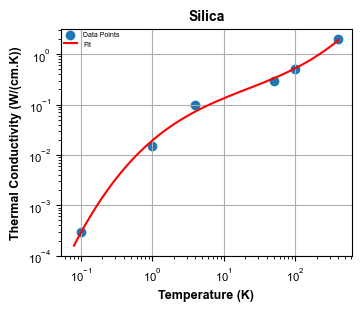

In [5]:
import matplotlib.pyplot as plt
from library.utils import fontstyle
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, 
                       ncols=1, 
                       figsize=(3.5, 3), 
                       constrained_layout=True)

# Plotting the results
x_vals = np.geomspace(0.08, 400, num=100)
y_vals = conductivity(x_vals)
ax.scatter(t_data, g_data, label='Data Points')
ax.loglog(x_vals, y_vals, color='red', label='Fit')
ax.set_title("Silica", fontproperties=title_font)
ax.set_xlabel('Temperature (K)', fontproperties=axis_label_font)
ax.set_ylabel('Thermal Conductivity (W/(cm.K))', fontproperties=axis_label_font)
for label in ax.get_yticklabels() :
        label.set_fontproperties(tick_label_font)

for label in ax.get_xticklabels() :
        label.set_fontproperties(tick_label_font)
    
ax.legend(prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.grid(True)

plt.savefig(f"./silica_k.png",dpi=600)
plt.show()

In [6]:
# Calculate the passive heat load (Watts) using integration
result, error = quad(conductivity, 50, 300) # 50K
PHL_Fiber_50K = result*area / l_50K
print(f"{PHL_Fiber_50K=:.5e}")

result, error = quad(conductivity, 4, 50) # 4K
PHL_Fiber_4K = result*area / l_4K
print(f"{PHL_Fiber_4K=:.5e}")

result, error = quad(conductivity, 1, 4) # Still
PHL_Fiber_Still = result*area / l_Still
print(f"{PHL_Fiber_Still=:.5e}")

result, error = quad(conductivity, 0.1, 1) # CP
PHL_Fiber_CP = result*area / l_CP
print(f"{PHL_Fiber_CP=:.5e}")

result, error = quad(conductivity, 0.01, 0.1) #MXC
PHL_Fiber_MXC = result*area / l_MXC
print(f"{PHL_Fiber_MXC=:.5e}")

PHL_Fiber_50K=3.35281e-05
PHL_Fiber_4K=1.61068e-06
PHL_Fiber_Still=2.58114e-08
PHL_Fiber_CP=2.02211e-09
PHL_Fiber_MXC=1.89649e-12
